# **Recovering injected behavioural biases from a synthetic trading record**
## **P01 — Behavioural Finance**

---

**Authors:** Alan Jesús Hernández Soto · Francisco Uriel Ledezma Chávez · Esteban Vega Campos · *(fourth member)*  
**Programme:** Ingeniería Financiera  
**Institution:** ITESO — Universidad Jesuita de Guadalajara  
**Course:** Comportamiento en las Finanzas y Toma de Decisiones  
**Professor:** Luis Felipe Gómez Estrada  
**Date:** 17 September 2026

---

## Contents

0. [The project in plain terms](#s0)
1. [Pre-analysis statement](#s1)
2. [Simulator design](#s2)
   - [2.1 The security universe](#s21)
   - [2.2 Traders and the injected mechanism](#s22)
   - [2.3 Trading costs, and what "gross" means here](#s23)
   - [2.4 Estimator conventions](#s24)
3. [Results across the eight scenarios](#s3)
4. [Validation](#s4)
5. [The scenarios where something happened](#s5)
6. [Diagnosing the turnover slope on gross returns](#s6)
7. [Independence of the injected parameters](#s7)
8. [Standard errors and clustering](#s8)
9. [What the estimators cannot distinguish](#s9)
10. [Conclusions](#s10)
11. [References](#s11)
12. [Reproducibility](#s12)

---

<a id="s0"></a>

## 0. The project in plain terms

With real brokerage data nobody can check whether a measured bias is genuine or the product of a coding error, because the true behaviour of each investor is unknown, so we built a simulated market in which it is known by construction. A thousand simulated investors trade sixty simulated stocks for three years, and we hide two behaviours in their decision rules at strengths we fix in advance, namely a tendency to sell winners faster than losers (the **disposition effect**) and a tendency to trade too often (**overprecision**, the form of overconfidence in which investors treat their own information as more precise than it is), after which we run the two standard measurements from the literature on the resulting trading record and compare what they report against what we hid.

The table below is the whole result in one place, and the rest of the notebook explains how each row was obtained and why the wrong answers occur.

| # | What we hid in the traders | What the disposition measure reports | What the turnover regression reports | Correct? |
|---|---|---|---|---|
| 1 | Nothing | No effect (ratio 1.02) | No effect | Yes |
| 2 | Mild disposition | Disposition (ratio 1.74) | Trading *raises* returns | Only the first |
| 3 | Strong disposition | Strong disposition (ratio 7.39) | Trading *raises* returns | Only the first |
| 4 | Mild overtrading | No effect (ratio 1.00) | Trading costs 0.78 pp of return per unit of turnover | Yes |
| 5 | Strong overtrading | No effect (ratio 1.00) | Trading costs 0.65 pp per unit of turnover, weakly significant | Yes |
| 6 | Both | Disposition (ratio 6.67) | Trading *raises* returns | Only the first |
| 7 | Nothing, but traders rebalance monthly | Disposition (ratio 1.83) | No effect | **No** |
| 8 | Nothing, but traders expect prices to revert | Disposition (ratio 1.41) | Trading *raises* returns | **No** |

In five of the eight scenarios at least one measurement returns a confident answer that is wrong, and none of the five is a bug, since each measurement computes exactly what it claims to compute and the error lies in reading that number as the behaviour behind it.

**A short glossary, used throughout.** A position's *basis* is its purchase price, so a position is a *paper gain* when today's price is above the basis and a *paper loss* when it is below. **PGR** (proportion of gains realised) is the share of paper gains an investor sells on the days they sell anything, and **PLR** is the same share for losses, so if an investor holding 10 gains and 10 losses sells 2 gains and 1 loss that day, PGR = 2/10 = 0.20 and PLR = 1/10 = 0.10, and a ratio PGR/PLR above one is the disposition effect. A *hazard* is simply the probability of selling a position on a given day, which is how we write the behaviour into each trader. **Turnover** is the fraction of the portfolio traded in a year, where a turnover of 1 means the whole portfolio was sold and replaced once. **Gross** returns ignore trading costs and **net** returns include them. A **standard error** measures how much an estimate would move if the experiment were repeated, a **t-statistic** is the estimate divided by it (values beyond about 2 are conventionally called significant), and a **bootstrap** estimates the standard error by recomputing the statistic on many resamples of the data.

---

<a id="s1"></a>

## 1. Pre-analysis statement

The assignment asks for one paragraph, written before any estimator is run, that states the parameters to be injected and what each estimator should recover. Ours was written on 13 September 2026 before the first estimator was run, and it is reproduced below exactly as it stands in `PRE_ANALYSIS.md` so that it cannot be adjusted after the fact, while how each prediction fared is scored at the end of section 4.

> We inject two parameters. The disposition strength `delta_i` enters as a multiplier on
> a daily sell hazard: a position trading above its purchase price has its immediate
> probability of sale scaled by `(1 + delta_i)`, one below its purchase price by
> `(1 - delta_i)`. The overprecision parameter `kappa_i` enters the same hazard as a
> level shift, `h_0 * (1 + 4 * kappa_i)`, so it governs how often an account acts at all
> without touching which domain it closes. Neither PGR, PLR nor turnover is parametrised
> anywhere in the code; all three are emergent. Per scenario, the tabulated `delta` and
> `kappa` are the means of independent Beta draws across the population, degenerate at
> zero where the scenario specifies zero.
>
> We expect the following. In scenario 1 both estimators should be quiet: PGR - PLR
> within two bootstrap standard errors of zero, and a turnover slope on gross returns
> indistinguishable from zero. In scenarios 2 and 3 we expect PGR - PLR to be positive
> and larger in 3 than in 2, monotone in the injected delta but not equal to it, since
> the hazard multiplier and the realized ratio are different quantities. In scenarios 4
> and 5 we expect the disposition estimator to stay quiet while the turnover slope on
> net returns turns negative and more negative as kappa rises, with the gross slope
> close to zero. Scenario 6 should show both, and we expect the measured disposition
> ratio to be attenuated relative to scenario 3 because higher churn shortens holding
> periods and moves positions closer to their purchase price. Scenarios 7 and 8 carry
> delta = 0 and we nonetheless expect a positive, statistically significant
> PGR - PLR in both: rebalancing trims the positions that have drifted up, and a belief
> in reversal keys on trailing returns that correlate with the gain indicator. Those two
> are the point of the exercise, not a failure of it.
>
> On the overconfidence side we expect the Barber-Odean contrast only where kappa
> carries the variation. Wherever the selling rule conditions on the purchase price
> (scenarios 2, 3, 6) or trims winners (scenario 7), we expect reverse causality to push
> the gross slope positive, because an account that happened to perform well holds more
> winners, sells more of them, and books higher turnover. Cash drag is eliminated by
> construction through same-day redeployment, and the bid-ask spread is excluded from
> the gross measure by definition, so neither should appear unless we deliberately
> switch them on.
>
> Finally, we expect the realized sample correlation between `delta_i` and `kappa_i` to
> be within Monte Carlo noise of zero by construction, and the correlation between
> `delta_i` and realized turnover to be materially negative, because a strong
> disposition agent holds losers indefinitely and thereby trades less.

In [1]:
# A kernel left running keeps the version of `bfsim` it first imported, and
# "Run All" does not restart it, so an edit to src/ would otherwise go unseen.
%load_ext autoreload
%autoreload 2

import os, sys, pathlib, warnings

# The library lives at the repository root and this study's outputs beside the
# notebook, so both are resolved from the root wherever the kernel starts.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "src" / "bfsim").is_dir())
os.chdir(ROOT / "studies" / "p01-disposition-overconfidence")
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace

from bfsim.config import (MASTER_SEED, PriceConfig, PopulationConfig, CostConfig,
                          EngineConfig, stream_rngs)
from bfsim.agents import draw_population
from bfsim import figures as fx
from bfsim.scenarios import (SCENARIOS, common_universe, analyse, run_all, results_table,
                             independence_table, convention_table, placebo_table,
                             discrimination_table, replicate_seeds)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.5f}")
FIG = "results/figures"

---

<a id="s2"></a>

## 2. Simulator design

<a id="s21"></a>

### 2.1 The security universe

Sixty stocks are simulated over 750 trading days, roughly three years, and instead of moving independently they share common drivers the way real stocks do, since each daily log return is built as

$$r_{j,t} \;=\; a_j \;+\; \beta^{M}_j f^{M}_t \;+\; \beta^{V}_j f^{V}_t \;+\; \beta^{S}_j f^{S}_t \;+\; \varepsilon_{j,t},$$

where $f^M$ is a market factor with 16 % annual volatility, $f^V$ and $f^S$ are two independent style factors with 10 % each, the betas measure how strongly stock $j$ responds to each factor (market betas are drawn around 1 and clipped to $[0.2,\,2.0]$), and $\varepsilon_{j,t}$ is the stock's own noise with an annual volatility between 20 % and 45 %. This factor structure matters for two reasons, because it reproduces the average pairwise correlation of about 0.19 that a real cross-section of stocks shows, and because it gives the overconfidence regression a meaningful risk control, since each portfolio's market beta then varies for reasons unrelated to how often its owner trades.

The intercept $a_j$ was changed during construction, and the reason is worth recording because it looked exactly like a violation of the assignment's central constraint. With a CAPM-style drift, in which riskier stocks earn more on average, the expected *log* return still falls with volatility, because it equals the expected simple return minus half the variance, so across our sixty stocks it varied with a standard deviation of 3.0 percentage points a year and a correlation of $-0.90$ with idiosyncratic volatility, which means that any rule selecting stocks on their past performance acquires a drift advantage or disadvantage it never had information about. We therefore impose the same expected log return of 6 % a year on every stock, which leaves the arithmetic means differing only by half the variance, an effect that cannot make a portfolio compound faster.

**The big constraint holds by construction**, because the entire price panel is drawn from its own random stream before a single trader exists and the trading engine only ever reads it, so no trading decision can reach the return that follows it, and section 4 tests the claim empirically in any case.

stocks 60   trading days 750
annualised volatility   mean 0.379   range [0.218, 0.501]
mean pairwise return correlation   0.1940
market beta   mean 1.061   sd 0.381
CAPM-style drift, rejected:  sd of expected log return 0.0299   corr with idiosyncratic vol -0.902
drift used instead: 0.060 per year on every stock


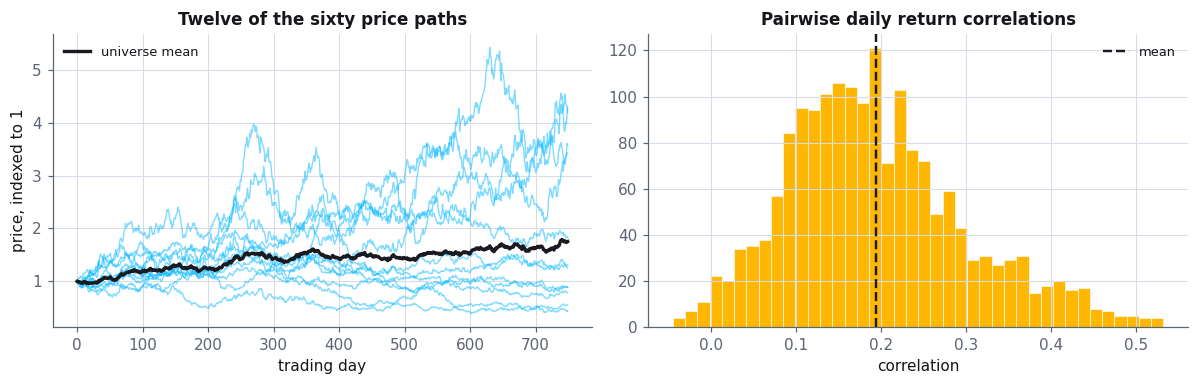

In [2]:
price_cfg = PriceConfig()
universe = common_universe(price_cfg)

r = np.diff(np.log(universe.prices), axis=0)
corr = np.corrcoef(r.T)
iu = np.triu_indices_from(corr, 1)
print(f"stocks {universe.n_securities}   trading days {universe.n_days}")
print(f"annualised volatility   mean {r.std(0).mean()*np.sqrt(252):.3f}   "
      f"range [{r.std(0).min()*np.sqrt(252):.3f}, {r.std(0).max()*np.sqrt(252):.3f}]")
print(f"mean pairwise return correlation   {corr[iu].mean():.4f}")
print(f"market beta   mean {universe.beta_market.mean():.3f}   sd {universe.beta_market.std():.3f}")

# What the rejected CAPM-style drift would have implied for expected log returns
total_var = ((universe.beta_market * price_cfg.market_vol_annual) ** 2
             + (universe.beta_style ** 2).sum(1) * price_cfg.style_vol_annual ** 2
             + universe.idio_vol ** 2)
capm_log_drift = (price_cfg.risk_free_annual
                  + universe.beta_market * price_cfg.market_premium_annual - 0.5 * total_var)
print(f"CAPM-style drift, rejected:  sd of expected log return {capm_log_drift.std():.4f}   "
      f"corr with idiosyncratic vol {np.corrcoef(capm_log_drift, universe.idio_vol)[0,1]:+.3f}")
print(f"drift used instead: {price_cfg.common_log_drift_annual:.3f} per year on every stock")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for j in np.linspace(0, universe.n_securities - 1, 12).astype(int):
    ax[0].plot(universe.prices[:, j] / universe.prices[0, j], lw=0.9, color=fx.BLUE, alpha=0.5)
ax[0].plot((universe.prices / universe.prices[0]).mean(axis=1), lw=2.2, color=fx.DARK,
           label="universe mean")
ax[0].set_title("Twelve of the sixty price paths"); ax[0].legend(fontsize=8.5)
ax[0].set_xlabel("trading day"); ax[0].set_ylabel("price, indexed to 1")
ax[1].hist(corr[iu], bins=40, color=fx.GOLD, edgecolor="white", linewidth=0.4)
ax[1].axvline(corr[iu].mean(), color=fx.DARK, lw=1.6, ls="--", label="mean")
ax[1].set_title("Pairwise daily return correlations"); ax[1].legend(fontsize=8.5)
ax[1].set_xlabel("correlation")
plt.tight_layout(); plt.savefig(f"{FIG}/universe.png", dpi=160, bbox_inches="tight"); plt.show()

<a id="s22"></a>

### 2.2 Traders and the injected mechanism

Each scenario generates a fresh population of $N=1000$ accounts, and each account receives a disposition strength $\delta_i$, an overprecision intensity $\kappa_i$, a starting capital $W_i$ between \$10,000 and \$500,000 drawn so that small accounts are more common than large ones, and a target number of positions $n_i$ between 5 and 30.

We read the $\delta$ and $\kappa$ of the scenario table as the *average* of the population rather than as a value every trader shares, drawing each trader's parameter from a Beta distribution with that mean, because without differences across traders there would be nothing to correlate in section 7 and the turnover regression would have almost no variation to work with. The two are drawn from separate random streams, so their independence follows from the construction rather than from checking it afterwards.

The behaviour is written into a single daily probability of selling each position the trader holds,

$$h_{i,j,t} \;=\; \underbrace{h_0\,\bigl(1 + 4\kappa_i\bigr)}_{\text{how often the trader acts}} \;\times\; \underbrace{\begin{cases} 1+\delta_i & \text{price above basis} \\ 1 & \text{price equal to basis} \\ 1-\delta_i & \text{price below basis}\end{cases}}_{\text{which positions it closes}}$$

with $h_0 = 0.004$, which makes an unbiased trader replace their portfolio about once a year, while $\kappa$ raises that frequency and $\delta$ tilts the selling toward winners. Nothing in this expression is PGR, which is the point the assignment insists on, since the estimator reads a quantity one level above the one we inject and the gap between them depends on how long positions are held and on the price path they follow, while the money from every sale is reinvested the same day in a stock chosen at random, independently of its past and its future.

delta   mean 0.796  sd 0.152
kappa   mean 0.303  sd 0.174
realised corr(delta, kappa) = -0.0060  (standard error under independence 0.0158)
capital  median $68,090   positions  mean 17.6


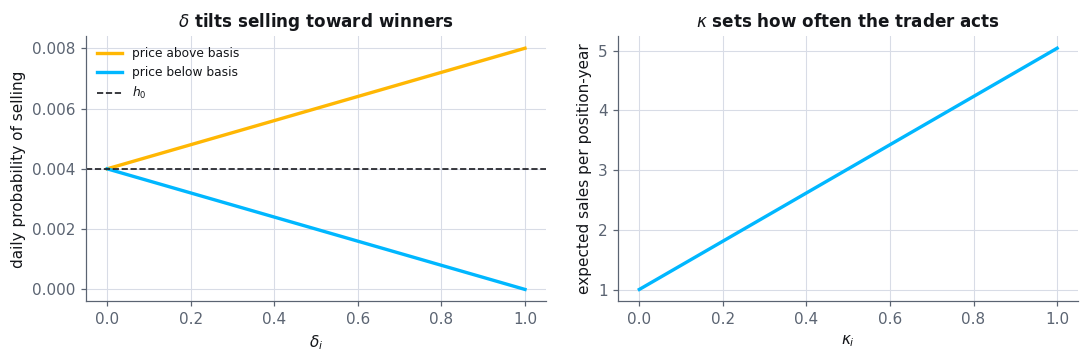

In [3]:
demo = draw_population(PopulationConfig(n_traders=4000, delta_mean=0.8, kappa_mean=0.3),
                       stream_rngs(99))
print(f"delta   mean {demo.delta.mean():.3f}  sd {demo.delta.std():.3f}")
print(f"kappa   mean {demo.kappa.mean():.3f}  sd {demo.kappa.std():.3f}")
print(f"realised corr(delta, kappa) = {np.corrcoef(demo.delta, demo.kappa)[0,1]:+.4f}  "
      f"(standard error under independence {1/np.sqrt(demo.n_traders-3):.4f})")
print(f"capital  median ${np.median(demo.wealth):,.0f}   positions  mean {demo.n_pos.mean():.1f}")

eng = EngineConfig()
d = np.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(d, eng.base_hazard*(1+d), color=fx.GOLD, lw=2.2, label="price above basis")
ax[0].plot(d, eng.base_hazard*(1-d), color=fx.BLUE, lw=2.2, label="price below basis")
ax[0].axhline(eng.base_hazard, color=fx.DARK, ls="--", lw=1.1, label=r"$h_0$")
ax[0].set_xlabel(r"$\delta_i$"); ax[0].set_ylabel("daily probability of selling")
ax[0].set_title(r"$\delta$ tilts selling toward winners"); ax[0].legend(fontsize=8)
k = np.linspace(0, 1, 100)
ax[1].plot(k, eng.base_hazard*(1+eng.kappa_multiplier*k)*252, color=fx.BLUE, lw=2.2)
ax[1].set_xlabel(r"$\kappa_i$"); ax[1].set_ylabel("expected sales per position-year")
ax[1].set_title(r"$\kappa$ sets how often the trader acts")
plt.tight_layout(); plt.savefig(f"{FIG}/mechanism.png", dpi=160, bbox_inches="tight"); plt.show()

<a id="s23"></a>

### 2.3 Trading costs, and what "gross" means here

Every trade pays a commission of 10 basis points of its value with a minimum of one dollar, and crosses a bid-ask spread of 30 basis points, so buyers pay 15 basis points above the mid price and sellers receive 15 below it, which makes a full round trip of the portfolio cost $2\times(10+15)=50$ basis points, the number to keep in mind when reading the overconfidence slope in section 3.

Each account also runs a *shadow portfolio* that copies its decisions exactly, buying and selling the same stocks on the same days, but trades at the mid price and pays no commission, and **gross return is the return of that shadow portfolio while net return is the return of the real one**. This definition removes by construction one of the problems the assignment warns about, since a gross return computed by adding costs back at the end would still carry the half-spread inside the purchase and sale prices, whereas the shadow portfolio never paid it, so any gap between gross and net is trading cost and nothing else.

<a id="s24"></a>

### 2.4 Estimator conventions

The disposition estimator counts, on every day an account sells something, how many of the positions it holds are gains sold ($G_r$), gains kept ($G_p$), losses sold ($L_r$) and losses kept ($L_p$), and pools the four counts across all accounts and days,

$$\widehat{PGR} = \frac{G_r}{G_r+G_p}, \qquad \widehat{PLR} = \frac{L_r}{L_r+L_p}.$$

Four choices decide what those counts mean, and because each one changes the answer we compute the alternative alongside our choice, with the magnitudes reported in section 5.

| Question | Our choice | Alternative also computed | Where it matters |
|---|---|---|---|
| Do days without a sale count? | No, only sale days contribute | Every day counts | Everywhere, since the difference shrinks by a factor of 4 to 12 when silent days are included |
| Is selling half a position one sale or half a sale? | One sale, and the remaining half is classified again the next day | Weighted by the fraction sold | Only in scenario 7, the only one that sells partial positions |
| Which purchase price? | Each purchase is its own lot | Average cost across lots of the same stock | Attenuates the estimate by about 8 % where the effect is large |
| A position exactly at its purchase price? | Counted as neither gain nor loss | Not needed | Never observed, since prices are continuous |

Standard errors come from a bootstrap that resamples whole **accounts**, since the positions of one account share that account's behaviour and are therefore not independent observations, and the naive version that resamples individual positions is computed only to show by how much it understates the uncertainty.

---

<a id="s3"></a>

## 3. Results across the eight scenarios

Each scenario regenerates the full population, while all eight share one price panel, because null recovery and monotonicity are comparisons *across* scenarios and a different market for each would mix the behavioural difference with a different realised market, a choice section 4 checks by redrawing the market eight times.

In [4]:
%%time
outputs = run_all(universe, n_boot=2000, verbose=False)
table = results_table(outputs)
table.to_csv("results/scenarios.csv")

disp_cols = ["Scenario", "delta_inj", "kappa_inj", "PGR", "se_PGR", "PLR", "se_PLR",
             "PGR-PLR", "se_diff", "t_diff", "PGR/PLR", "se_ratio", "Turnover"]
table[disp_cols]

CPU times: total: 25.4 s
Wall time: 27.2 s


,Scenario,delta_inj,kappa_inj,PGR,se_PGR,PLR,se_PLR,PGR-PLR,se_diff,t_diff,PGR/PLR,se_ratio,Turnover
#,,,,,,,,,,,,,
1,Null,0.00000,0.00000,0.05099,0.00057,0.05014,0.00058,0.00085,0.00044,1.95000,1.01694,0.00877,1.00461
2,"Disposition only, low",0.30000,0.00000,0.06245,0.00071,0.03582,0.00051,0.02663,0.00076,35.08984,1.74344,0.02755,1.07208
3,"Disposition only, high",0.80000,0.00000,0.08660,0.00093,0.01173,0.00033,0.07487,0.00102,73.35749,7.38544,0.22776,1.06837
4,"Turnover only, low",0.00000,0.30000,0.05370,0.00056,0.05360,0.00057,0.00010,0.00031,0.33379,1.00191,0.00572,2.22766
5,"Turnover only, high",0.00000,0.80000,0.05700,0.00052,0.05728,0.00053,-0.00029,0.00023,-1.24497,0.99500,0.00400,4.24579
6,Both active,0.80000,0.80000,0.11581,0.00135,0.01735,0.00037,0.09846,0.00148,66.50418,6.67371,0.17791,3.36125
7,Rebalancing confound,0.00000,0.00000,0.07355,0.00065,0.04016,0.00042,0.03338,0.00048,70.24093,1.83112,0.01415,1.19450
8,Mean-reversion confound,0.00000,0.00000,0.05754,0.00059,0.04067,0.00047,0.01686,0.00044,38.06657,1.41463,0.01255,1.04668


In [5]:
table[["Scenario", "beta_gross", "se_gross", "t_gross", "beta_net", "se_net", "t_net"]]

,Scenario,beta_gross,se_gross,t_gross,beta_net,se_net,t_net
#,,,,,,,
1,Null,0.00123,0.01557,0.07912,-0.00474,0.01549,-0.30576
2,"Disposition only, low",0.06266,0.01498,4.18385,0.05648,0.01491,3.78707
3,"Disposition only, high",0.15070,0.01340,11.24510,0.14368,0.01331,10.79433
4,"Turnover only, low",-0.00183,0.00343,-0.53299,-0.00776,0.00338,-2.29681
5,"Turnover only, high",-0.00056,0.00354,-0.15817,-0.00647,0.00348,-1.85902
6,Both active,0.02820,0.00355,7.94201,0.02180,0.00348,6.27091
7,Rebalancing confound,0.01354,0.01522,0.88948,0.00788,0.01515,0.51968
8,Mean-reversion confound,0.06403,0.01466,4.36751,0.05796,0.01459,3.97311


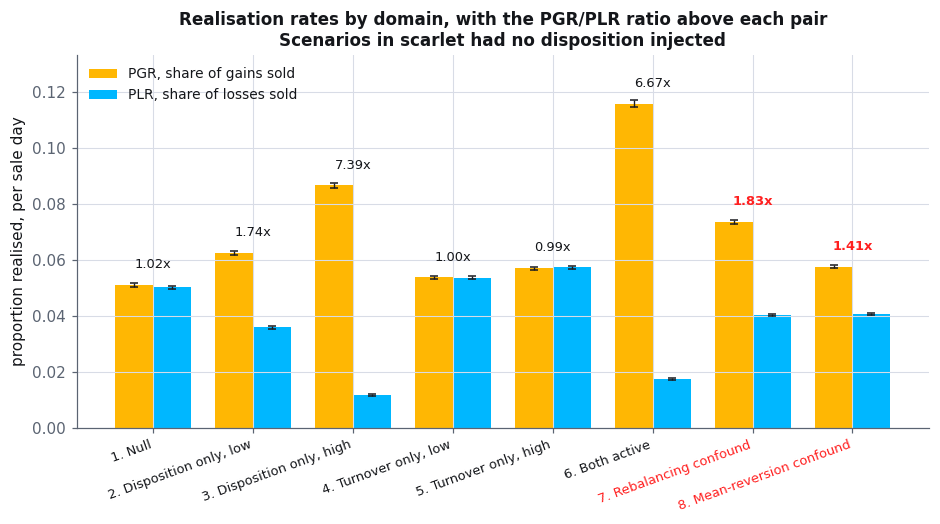

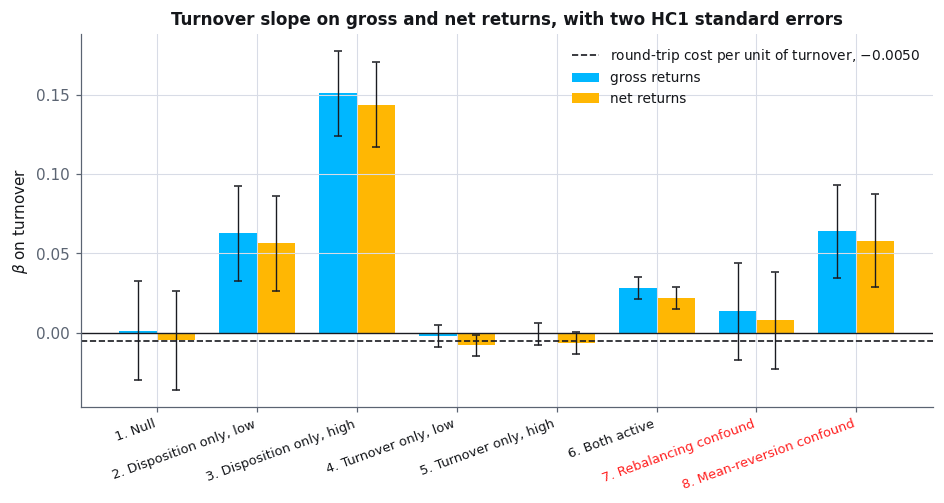

round-trip cost per unit of annual turnover: 0.00500


,mean turnover,"mean cost drag, per year"
1,1.00461,0.00606
2,1.07208,0.00642
3,1.06837,0.00644
4,2.22766,0.01337
5,4.24579,0.02528
6,3.36125,0.01989
7,1.19450,0.00875
8,1.04668,0.00629


In [6]:
fx.pgr_plr_bars(table, f"{FIG}/pgr_plr.png"); plt.show()
cost_rate = 2 * (CostConfig().commission_bps + CostConfig().half_spread_bps) * 1e-4
fx.slopes(table, cost_rate, f"{FIG}/slopes.png"); plt.show()
drag = pd.DataFrame({k: {"mean turnover": outputs[k].df.turnover.mean(),
                         "mean cost drag, per year": outputs[k].df.cost_drag.mean()}
                     for k in outputs}).T
print(f"round-trip cost per unit of annual turnover: {cost_rate:.5f}")
drag

**Reading the table.** The null is quiet, the disposition estimator rises with the injected $\delta$, and the two overtrading scenarios leave it undisturbed at $+0.0001$ and $-0.0003$, while on the overconfidence side scenarios 4 and 5 reproduce the pattern Barber and Odean report, with a gross slope indistinguishable from zero ($-0.0018$ and $-0.0006$) and a negative net slope ($-0.0078$ and $-0.0065$). Both net slopes lie within one standard error of $-0.005$, which is the round-trip cost written into the model, so the regression is not measuring a behavioural parameter at all but recovering the commission and spread schedule, which is at once the strongest validation in the exercise and the clearest limit on what the test can claim.

This also explains why the net slope does not become more negative from scenario 4 to scenario 5, contrary to what we predicted, since the slope is a cost per unit of turnover and the cost schedule is identical in both, so what rises with $\kappa$ is the level of the drag, from 1.34 % of return a year in scenario 4 to 2.53 % in scenario 5, and not the coefficient.

The rows that deserve attention are 6, 7 and 8, taken up in section 5, and the positive gross slopes of scenarios 2, 3, 6 and 8, taken up in section 6.

---

<a id="s4"></a>

## 4. Validation

Four things have to hold before the results can be believed, namely that the null comes back empty, that the recovered effect moves with the injected parameter, that each estimator stays quiet when only the other one's parameter is active, and that no information about future prices leaked into the trading decisions.

**Leakage.** The test compares the return over the next 20 days of every stock an agent bought against the average stock on the same day, so a rule that systematically picked future winners or losers would show a non-zero difference. The first version of this test returned a $t$ of $-7.5$ in scenario 7, which would have meant a violation of the constraint, yet the cell below shows the panel itself carries no predictability and the fault lay in the test, because a thousand accounts buying the same stock on the same day is one purchase counted a thousand times. Keeping each (day, stock) pair once and computing the standard error from daily averages, so that purchases sharing the same market day are not treated as independent, brings every scenario inside $|t|\le 2.2$, which across eight tests is what the absence of leakage looks like.

In [7]:
placebo = placebo_table(outputs)
placebo.to_csv("results/placebo.csv")

# The first, naive version of the test: every account's purchase counted separately.
run7, h = outputs[7].run, 20
keep = run7.buy_days + h < universe.n_days
d7, s7 = run7.buy_days[keep], run7.buy_secs[keep]
fwd = universe.prices[d7 + h, s7] / universe.prices[d7, s7] - 1
bench = (universe.prices[h:] / universe.prices[:-h] - 1)[d7].mean(axis=1)
excess = fwd - bench
print(f"naive placebo, scenario 7: n = {excess.size:,}   "
      f"t = {excess.mean() / (excess.std(ddof=1) / np.sqrt(excess.size)):+.2f}")

# Does the price panel itself contain short-horizon reversal?  It should not.
P = universe.prices
past = P[h:-h] / P[:-2*h] - 1;  past -= past.mean(axis=1, keepdims=True)
nxt = P[2*h:] / P[h:-h] - 1;    nxt -= nxt.mean(axis=1, keepdims=True)
losers = np.take_along_axis(nxt, np.argsort(past, axis=1)[:, :12], axis=1).mean(axis=1)
print(f"panel check: mean corr(past 20d, next 20d) = "
      f"{np.mean([np.corrcoef(a, b)[0, 1] for a, b in zip(past, nxt)]):+.4f}   "
      f"bottom-quintile forward excess t = {losers.mean() / (losers.std(ddof=1) / np.sqrt(losers.size)):+.2f}")
placebo

naive placebo, scenario 7: n = 289,848   t = -7.51
panel check: mean corr(past 20d, next 20d) = +0.0234   bottom-quintile forward excess t = +0.12


,Scenario,n_trades,n_pairs,n_days,diff,t_stat,diff_log,t_log
#,,,,,,,,
1,Null,67370,29942,730,0.00023,0.65699,0.00023,0.68518
2,"Disposition only, low",69492,30387,730,0.00046,1.25727,0.00047,1.31403
3,"Disposition only, high",65460,28499,730,-0.00007,-0.47380,-0.00008,-0.50197
4,"Turnover only, low",129447,40326,730,0.00020,1.41307,0.00019,1.33340
5,"Turnover only, high",236053,43500,730,-0.00000,-0.08261,-0.00000,-0.09316
6,Both active,169512,41739,730,-0.00025,-2.19760,-0.00023,-2.12047
7,Rebalancing confound,289848,30838,730,-0.00004,0.06206,-0.00001,0.14804
8,Mean-reversion confound,68882,30246,730,-0.00046,-1.30393,-0.00051,-1.49034


**Null recovery.** Within the shared price panel the null returns $\widehat{PGR}-\widehat{PLR} = 0.00085$ with a standard error of 0.00044, a $t$ of 1.95 that sits on the edge of significance for an effect that is zero by construction, whereas across eight independently redrawn markets the mean is 0.00022 with a standard deviation of 0.00050, a $t$ of 1.2, so the null is genuinely quiet and what misleads is the single-panel $t$. The reason is that every account in the sample lives through the same market, and resampling accounts, which correctly handles the dependence *within* an account, still treats a shared market shock as independent information across accounts, so a disposition ratio of 1.02 with a $t$ of 2 measured on one brokerage dataset is not evidence of anything, and finding this out requires redrawing the market, which a researcher with a single real dataset cannot do.

**Monotonicity.** The recovered difference rises from 0.00085 to 0.0266 to 0.0749 as $\delta$ goes from 0 to 0.3 to 0.8, and the ratio from 1.02 to 1.74 to 7.39, with the scenario 3 ratio stable at $7.34\pm0.38$ across the eight redrawn markets, and the recovery is monotone without being proportional because $\delta$ multiplies a daily probability while the ratio measures what that multiplier does to a proportion once holding periods and price paths intervene.

**Cross-estimator quiet holds in one direction only.** The disposition estimator stays silent in the two overtrading scenarios, at $t = 0.33$ and $t = -1.24$, but the overconfidence estimator does not stay silent in the two disposition scenarios, returning gross slopes of $+0.063$ and $+0.151$ with $t$ of 4.2 and 11.2 in populations with no overprecision whatsoever, so the disposition mechanism contaminates the overconfidence estimator while the reverse does not happen, a failed check that section 6 traces to reverse causality.

In [8]:
%%time
seeds = [20260913, 7, 101, 4242, 31337, 2, 13, 55]
reps = {}
for i in (0, 2, 6):
    cfg = SCENARIOS[i]
    reps[cfg.index] = replicate_seeds(cfg, seeds, n_boot=300)
    reps[cfg.index].to_csv(f"results/replication_s{cfg.index}.csv")

summary = pd.DataFrame({
    f"Scenario {k}": r[["PGR-PLR", "ratio", "beta_gross"]].agg(["mean", "std", "min", "max"]).stack()
    for k, r in reps.items()})
summary

CPU times: total: 58.8 s
Wall time: 59.1 s


Scenario 1  Scenario 3  Scenario 7
mean PGR-PLR        0.00022     0.07622     0.03202
     ratio          1.00446     7.33842     1.80195
     beta_gross     0.00313     0.14068     0.02273
std  PGR-PLR        0.00050     0.00581     0.00271
     ratio          0.01003     0.37522     0.06729
     beta_gross     0.01551     0.01328     0.01243
min  PGR-PLR       -0.00062     0.06892     0.02797
     ratio          0.98778     6.74915     1.69115
     beta_gross    -0.01359     0.11300     0.01264
max  PGR-PLR        0.00085     0.08399     0.03457
     ratio          1.01694     7.72766     1.85616
     beta_gross     0.02782     0.15070     0.04496

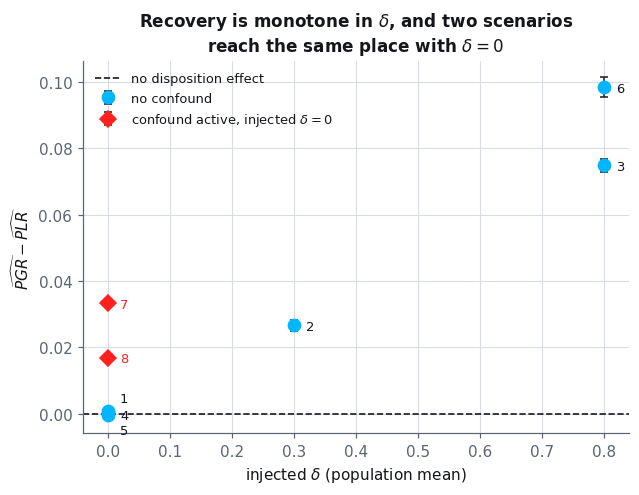

In [9]:
fx.monotonicity(table, f"{FIG}/monotonicity.png"); plt.show()

**How the pre-registered predictions fared.** Most of the predictions held, three failed in whole or in part, and one outcome was not predicted at all.

| Prediction in section 1 | Outcome | Verdict |
|---|---|---|
| Scenario 1 quiet on both estimators | Difference 0.00085 ($t$ = 1.95 in one market, 1.2 across eight) and gross slope $t$ = 0.08 | Held |
| Scenarios 2 and 3 positive, larger in 3, monotone but not equal to $\delta$ | 0.0266 and 0.0749, ratios 1.74 and 7.39 | Held |
| Scenarios 4 and 5 quiet on disposition, gross slope near zero, net slope negative | Disposition $t$ of 0.33 and $-1.24$, gross slope $t$ of $-0.53$ and $-0.16$, net slope $-0.0078$ and $-0.0065$ | Held |
| Net slope *more negative* in 5 than in 4 | $-0.0065$ against $-0.0078$, since the slope is a cost rate | **Failed** |
| Scenario 6 ratio attenuated relative to scenario 3 | 6.67 against 7.39, although the difference rose | Held |
| Scenarios 7 and 8 positive and significant with $\delta = 0$ | $t$ of 70 and 38 | Held |
| Reverse causality makes the gross slope positive in scenarios 2, 3, 6 and 7 | Positive and significant in 2, 3 and 6, while in 7 it is $t$ = 0.89 in the shared market yet positive in all eight redrawn ones | Partly failed |
| No cash drag and no spread in the gross measure | Gross slope $t$ of $-0.53$ and $-0.16$ in scenarios 4 and 5 | Held |
| $\mathrm{corr}(\delta,\kappa)$ near zero | $-0.040$ against a standard error of 0.032 | Held |
| $\mathrm{corr}(\delta,\text{turnover})$ materially negative | $+0.136$ in scenario 2, $-0.112$ in 3 and $-0.617$ in 6 | **Failed** at low $\delta$ |
| *Not predicted* | Scenario 8 also produces a positive gross slope, $+0.064$ with $t$ = 4.4 | New |

---

<a id="s5"></a>

## 5. The scenarios where something happened

### 5.1 Scenario 6: the difference is not a scale-free measure of the bias

Scenario 6 injects $\delta = 0.8$ and $\kappa = 0.8$ together, and its ratio falls from 7.39 to 6.67 relative to scenario 3 as predicted, while the difference moves the other way, from 0.0749 to 0.0985. The difference is not scale-free, because raising $\kappa$ raises both realisation rates roughly in proportion, with PGR going from 0.0866 to 0.1158 and PLR from 0.0117 to 0.0174, so the same multiplicative tilt produces a larger absolute gap simply because both levels are higher, and a researcher reporting only the difference would conclude that the traders of scenario 6 are 32 % more disposition-prone than those of scenario 3 when both carry the same injected $\delta$ and differ only in how often they trade, which is why the ratio has to be reported next to the difference.

In [10]:
conv = convention_table(outputs)
conv.to_csv("results/conventions.csv")
conv

,Scenario,"per-lot, position","per-lot, share-weighted","average cost, position",silent days included,"ratio, sale days only","ratio, silent days included",at basis (obs),se (account),se (position-day),understatement
#,,,,,,,,,,,
1,Null,0.00085,0.00085,0.00046,0.00005,1.01694,1.01341,0,0.00044,0.00045,0.97645
2,"Disposition only, low",0.02663,0.02663,0.02425,0.00239,1.74344,1.85844,0,0.00076,0.00042,1.81868
3,"Disposition only, high",0.07487,0.07487,0.06909,0.00638,7.38544,9.14414,0,0.00102,0.00044,2.31986
4,"Turnover only, low",0.00010,0.00010,-0.00016,-0.00009,1.00191,0.98993,0,0.00031,0.00030,1.00837
5,"Turnover only, high",-0.00029,-0.00029,-0.00027,-0.00016,0.99500,0.99060,0,0.00023,0.00024,0.96891
6,Both active,0.09846,0.09846,0.08966,0.02611,6.67371,8.71216,0,0.00148,0.00032,4.62760
7,Rebalancing confound,0.03338,0.00754,0.03326,0.00361,1.83112,1.84651,0,0.00048,0.00040,1.19089
8,Mean-reversion confound,0.01686,0.01686,0.01684,0.00138,1.41463,1.43292,0,0.00044,0.00043,1.04194


The conventions table also prices the choices of section 2.4, since counting every day instead of only sale days shrinks the scenario 3 difference from 0.0749 to 0.0064 and moves the ratio from 7.39 to 9.14, which shows that the sale-day rule is not a neutral bookkeeping choice but one that changes the level of both statistics, and although the differences keep their ordering across scenarios under either rule, the ratios do not, since scenarios 2 and 7 trade places (1.86 against 1.85 when silent days count), so a genuine disposition of 0.3 outranks rebalancing under one convention and not under the other.

### 5.2 Scenario 7: rebalancing, and the convention that gives it away

Scenario 7 injects nothing at all, since its traders simply keep equal weights by trimming, once a month, any position that has grown more than 25 % above its target and topping up the positions below it, and yet the estimator returns a difference of 0.0334 with a $t$ of 70 and a ratio of 1.83, larger than the 1.74 that a genuine $\delta$ of 0.3 produces in scenario 2 and above the ratio of about 1.5 implied by the PGR of 0.148 and PLR of 0.098 that Odean (1998) reports for real brokerage accounts. Across eight redrawn markets it stays at $0.0320\pm0.0027$, so the result does not depend on one market path, and the mechanism is arithmetic rather than psychological, because a stock that rises gains weight and gets trimmed while one that falls loses weight and gets topped up, so the rule sells winners and buys losers because that is what equal weighting means.

What gives it away is the partial-sale convention, since rebalancing trims rather than closes, with a mean fraction sold of 0.712 against exactly 1.000 in every other scenario, so weighting each sale by the fraction sold collapses the estimate from 0.0334 to 0.0075 while leaving every other scenario unchanged to five decimals, which is a test anyone can run on real data where the size of each sale is recorded.

### 5.3 Scenario 8: a belief in reversal with the same appearance

Scenario 8 also injects nothing, and its traders believe that recent winners will fall back, so their probability of selling rises with the stock's return over the last 20 days, a rule that never looks at the purchase price but still produces a difference of 0.0169 with a $t$ of 38 and a ratio of 1.41, because a stock that rose recently is usually also above its purchase price. This case is harder to unmask than rebalancing, because the sales are of whole positions and the partial-sale test leaves it at 0.0169, so the evidence has to come from something other than the purchase price, namely the recent performance of what was sold compared with what was kept on the same days, measured as a 20-day return in standard deviations, which is what the *z* columns of the table below report.

In [11]:
disc = discrimination_table(outputs)
# The ratio is only meaningful where a disposition effect was measured at all;
# dividing a momentum tilt of 0.002 by a difference of 0.0001 is noise over noise.
disc["z tilt per unit of measured disposition"] = np.where(
    disc["PGR-PLR"] > 0.01, disc["z tilt"] / disc["PGR-PLR"], np.nan)
disc.to_csv("results/discrimination.csv")
disc

,Scenario,PGR-PLR,mean fraction sold,share-weighted PGR-PLR,"momentum z, sold","momentum z, held",z tilt,z tilt per unit of measured disposition
#,,,,,,,,
1,Null,0.00085,1.00000,0.00085,0.00171,-0.00041,0.00211,NaN
2,"Disposition only, low",0.02663,1.00000,0.02663,0.08520,-0.00403,0.08923,3.35091
3,"Disposition only, high",0.07487,1.00000,0.07487,0.25872,-0.00795,0.26666,3.56149
4,"Turnover only, low",0.00010,1.00000,0.00010,0.00236,0.00001,0.00235,NaN
5,"Turnover only, high",-0.00029,1.00000,-0.00029,0.00005,-0.00017,0.00022,NaN
6,Both active,0.09846,1.00000,0.09846,0.33696,-0.05072,0.38768,3.93752
7,Rebalancing confound,0.03338,0.71225,0.00754,0.57087,-0.00391,0.57478,17.21846
8,Mean-reversion confound,0.01686,1.00000,0.01686,0.52299,-0.02379,0.54678,32.42273


A reference-point rule also tilts that comparison, since winners against the purchase price tend to be recent winners too, so scenario 3 sells stocks whose recent return is 0.267 standard deviations above those it keeps, but per unit of measured disposition the tilt is 32.4 in scenario 8 and 17.2 in scenario 7 against 3.6 in scenario 3 and 3.4 in scenario 2, so an account whose sales follow recent returns far more closely than its disposition measure would suggest is not following a reference point.

---

<a id="s6"></a>

## 6. Diagnosing the turnover slope on gross returns

The assignment lists four legitimate reasons why gross returns could fall with turnover, plus reverse causality, which pushes the slope up instead, and asks which one is present. **No negative gross slope appears in any scenario**, since it is $-0.0018$ ($t = -0.53$) and $-0.0006$ ($t = -0.16$) where $\kappa$ drives turnover, while it is strongly *positive* in scenarios 2, 3, 6 and 8, so the diagnosis has two parts, why nothing negative appears and what the positive slope is.

Leakage is excluded by the placebo of section 4, and the spread is excluded by the shadow-portfolio definition of section 2.3, while cash drag is excluded because proceeds are reinvested the same day, and compounding effects cannot be detected here, since in scenario 5 the correlation between turnover and gross return is $-0.020$ against a standard error of 0.032. Rather than only argue that cash drag is absent, we switch it on by making sale proceeds wait one, three or five days before they can be reinvested.

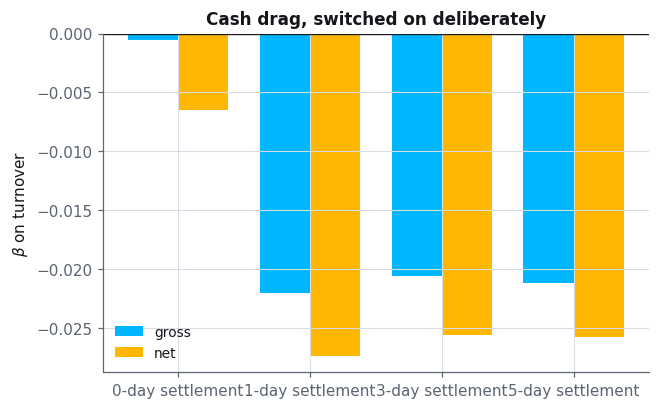

CPU times: total: 10.7 s
Wall time: 10.8 s


,beta_gross,t_gross,beta_net,t_net,mean gross return,mean turnover
settlement lag,,,,,,
0,-0.00056,-0.15817,-0.00647,-1.85902,0.18648,4.24579
1,-0.02202,-4.77485,-0.02738,-6.05722,0.16239,4.01367
3,-0.02060,-3.63205,-0.02555,-4.58990,0.14515,4.05721
5,-0.02118,-3.40419,-0.02577,-4.20994,0.13124,4.06105


In [12]:
%%time
rows = []
for lag in (0, 1, 3, 5):
    o = analyse(replace(SCENARIOS[4], engine=replace(EngineConfig(), settlement_lag=lag)),
                universe, n_boot=300)
    rows.append({"settlement lag": lag,
                 "beta_gross": o.over["ret_gross"]["beta"], "t_gross": o.over["ret_gross"]["t"],
                 "beta_net": o.over["ret_net"]["beta"], "t_net": o.over["ret_net"]["t"],
                 "mean gross return": o.df.ret_gross.mean(),
                 "mean turnover": o.df.turnover.mean()})
lagged = pd.DataFrame(rows).set_index("settlement lag")
lagged.to_csv("results/cash_drag.csv")
fx.cash_drag(lagged.index.tolist(), lagged["beta_gross"], lagged["beta_net"], f"{FIG}/cash_drag.png")
plt.show()
lagged

A single idle day between sale and reinvestment takes the gross slope from $-0.0006$ ($t = -0.16$) to $-0.0220$ ($t = -4.77$) and lowers the population's mean gross return from 18.6 % to 16.2 %, falling to 13.1 % with a five-day wait, without any informed trading, because a frequent trader simply spends more time out of a market that rises on average. This is the case in which a researcher would wrongly conclude that frequent traders pick bad stocks, and what distinguishes it is that the damage grows with the time spent in cash rather than with anything about the stocks bought, which the placebo would confirm by staying silent.

**The positive slope is reverse causality**, and the simulation lets us show it rather than argue it, since in scenario 3 the injected $\delta$ is essentially uncorrelated with gross return ($-0.026$) while realised turnover correlates $+0.397$ with it, so turnover is partly a *consequence* of the return, because an account whose stocks happened to rise holds more winners and a rule that sells winners faster turns that luck into trades, which makes the regression of return on turnover read the arrow backwards. Where $\kappa$ varies across traders we can go one step further and replace realised turnover, which is an outcome, by $\kappa$, which is its cause and cannot be affected by returns, the same logic an instrumental variable exploits, since it uses a variable that moves turnover without being moved by returns.

In [13]:
inst = pd.DataFrame({
    k: {"beta on realised turnover, gross": outputs[k].over["ret_gross"]["beta"],
        "beta on injected kappa, gross": outputs[k].over["ret_gross_kappa"]["beta"],
        "beta on injected kappa, net": outputs[k].over["ret_net_kappa"]["beta"],
        "corr(delta, ret_gross)": outputs[k].indep["corr_delta_retgross"],
        "corr(turnover, ret_gross)": outputs[k].indep["corr_turnover_retgross"]}
    for k in (2, 3, 5, 6, 7, 8)}).T
inst.index.name = "#"
inst

,"beta on realised turnover, gross","beta on injected kappa, gross","beta on injected kappa, net","corr(delta, ret_gross)","corr(turnover, ret_gross)"
#,,,,,
2,0.06266,NaN,NaN,-0.01608,0.15499
3,0.15070,NaN,NaN,-0.02618,0.39749
5,-0.00056,0.00857,-0.01534,NaN,-0.02036
6,0.02820,0.00813,-0.00903,0.01337,0.28036
7,0.01354,NaN,NaN,NaN,0.02215
8,0.06403,NaN,NaN,NaN,0.14230


In scenario 5, where selling never looks at the purchase price, the regression on $\kappa$ gives $+0.009$ on gross returns and $-0.015$ on net returns, the Barber-Odean contrast in its clean form, while in scenario 6, where both parameters are active, the same substitution takes the gross coefficient from $+0.028$ to $+0.008$ and the net coefficient from $+0.022$ to $-0.009$. The sign of the net slope, which carries the entire behavioural claim, therefore depends on whether the regression uses the outcome or the cause, and in scenarios 2, 3, 7 and 8 no such substitution exists because $\kappa$ does not vary, which is exactly the situation of a researcher working with real data.

---

<a id="s7"></a>

## 7. Independence of the injected parameters

The assignment asks four things here, that the two parameters be drawn independently, that their realised correlation be reported, that the correlation between $\delta$ and realised turnover be explained, and that we discuss what would happen had the parameters been correlated by construction.

In [14]:
indep = independence_table(outputs)
indep.to_csv("results/independence.csv")
indep

,Scenario,gain_share,corr_delta_kappa,se_corr_null,corr_delta_turnover,corr_kappa_turnover,corr_delta_retgross,corr_turnover_retgross
#,,,,,,,,
1,Null,0.58051,NaN,0.03167,NaN,NaN,NaN,-0.01215
2,"Disposition only, low",0.54819,NaN,0.03167,0.13623,NaN,-0.01608,0.15499
3,"Disposition only, high",0.50215,NaN,0.03167,-0.11245,NaN,-0.02618,0.39749
4,"Turnover only, low",0.55305,NaN,0.03167,NaN,0.93889,NaN,-0.02436
5,"Turnover only, high",0.53540,NaN,0.03167,NaN,0.85916,NaN,-0.02036
6,Both active,0.38694,-0.04048,0.03167,-0.61651,0.58819,0.01337,0.28036
7,Rebalancing confound,0.59655,NaN,0.03167,NaN,NaN,NaN,0.02215
8,Mean-reversion confound,0.54917,NaN,0.03167,NaN,NaN,NaN,0.14230


**(1) and (2).** The two parameters come from separate random streams, and scenario 6, the only one in which both vary across traders, gives $\mathrm{corr}(\delta_i,\kappa_i) = -0.040$ against a standard error of 0.032 under independence, a $t$ of $-1.3$, while in every other scenario one of the two is constant and the correlation is undefined, which the table shows as a missing value rather than a zero.

**(3) The correlation between $\delta$ and realised turnover is not zero, and its sign changes**, from $+0.136$ in scenario 2 to $-0.112$ in scenario 3 and $-0.617$ in scenario 6, because the injected parameter and the behaviour it produces are different objects connected through the composition of the portfolio. A trader's average probability of selling is $h_0[(1+\delta)p_g + (1-\delta)p_l] = h_0[1+\delta(p_g-p_l)]$, where $p_g$ is the share of positions showing a gain, so two forces pull in opposite directions, since in a rising market most positions are gains and a larger $\delta$ raises selling on that larger group, which dominates at $\delta = 0.3$, while a trader who holds losers longer accumulates them and shrinks the group the tilt acts on. The `gain_share` column shows that second force directly, falling from 0.581 in the null to 0.548 in scenario 2, 0.502 in scenario 3 and 0.387 in scenario 6, so at high $\delta$ the accumulation of losers wins and the correlation turns negative, strongly so when the higher trading of scenario 6 lets the composition adjust faster, and turnover is therefore an equilibrium of the mechanism rather than a direct reading of either parameter.

**(4) What correlated parameters would do.** We rerun scenario 6 making traders with a strong disposition also trade more often (a correlation of $+0.7$) or less often ($-0.7$), imposed through a Gaussian copula, which is simply a way of correlating two variables while keeping each one's Beta distribution.

In [15]:
%%time
rows = []
for rho in (0.0, 0.7, -0.7):
    o = analyse(replace(SCENARIOS[5], copula_rho=rho), universe, n_boot=300)
    rows.append({"imposed correlation": rho,
                 "realised corr(delta,kappa)": o.indep["corr_delta_kappa"],
                 "corr(delta,turnover)": o.indep["corr_delta_turnover"],
                 "beta_gross": o.over["ret_gross"]["beta"],
                 "beta_net": o.over["ret_net"]["beta"],
                 "PGR-PLR": o.disp["diff"]})
copula = pd.DataFrame(rows).set_index("imposed correlation")
copula.to_csv("results/copula.csv")
copula

CPU times: total: 7.53 s
Wall time: 7.57 s


,"realised corr(delta,kappa)","corr(delta,turnover)",beta_gross,beta_net,PGR-PLR
imposed correlation,,,,,
0.00000,-0.04048,-0.61651,0.02820,0.02180,0.09846
0.70000,0.67697,-0.25671,0.04517,0.03836,0.10401
-0.70000,-0.60934,-0.82034,0.02196,0.01567,0.10036


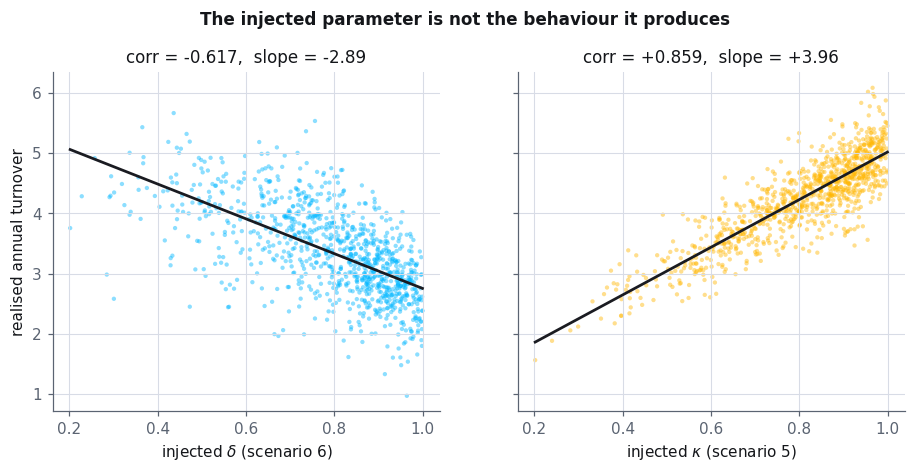

In [16]:
fx.turnover_vs_parameters(outputs[6].df, outputs[5].df, f"{FIG}/turnover_params.png"); plt.show()

The disposition estimate barely moves, at 0.0985, 0.1040 and 0.1004, whereas the overconfidence slope on gross returns goes from $+0.028$ to $+0.045$ and $+0.022$, and on net returns from $+0.022$ to $+0.038$ and $+0.016$, so the coefficient meant to price trading moves by 60 % because of a parameter that has nothing to do with costs. A positive correlation partly cancels the composition effect of point (3), taking $\mathrm{corr}(\delta,\text{turnover})$ from $-0.617$ to $-0.257$, so traders with strong disposition no longer trade distinctively less and the share of turnover driven by the disposition mechanism changes, which leaves $\beta$ as a blend of the cost of trading and the disposition mechanism's effect on trade frequency, interpretable as neither.

---

<a id="s8"></a>

## 8. Standard errors and clustering

The positions of one account share its $\delta$, its holding periods and often its stocks, so treating each position-day as an independent observation overstates how much information the data contain, and the simulation measures by how much.

In [17]:
se = conv[["Scenario", "se (account)", "se (position-day)", "understatement"]].copy()
se["t, resampling accounts"] = table["PGR-PLR"] / conv["se (account)"]
se["t, resampling position-days"] = table["PGR-PLR"] / conv["se (position-day)"]
se

,Scenario,se (account),se (position-day),understatement,"t, resampling accounts","t, resampling position-days"
#,,,,,,
1,Null,0.00044,0.00045,0.97645,1.95000,1.90409
2,"Disposition only, low",0.00076,0.00042,1.81868,35.08984,63.81729
3,"Disposition only, high",0.00102,0.00044,2.31986,73.35749,170.17878
4,"Turnover only, low",0.00031,0.00030,1.00837,0.33379,0.33659
5,"Turnover only, high",0.00023,0.00024,0.96891,-1.24497,-1.20626
6,Both active,0.00148,0.00032,4.62760,66.50418,307.75444
7,Rebalancing confound,0.00048,0.00040,1.19089,70.24093,83.64892
8,Mean-reversion confound,0.00044,0.00043,1.04194,38.06657,39.66293


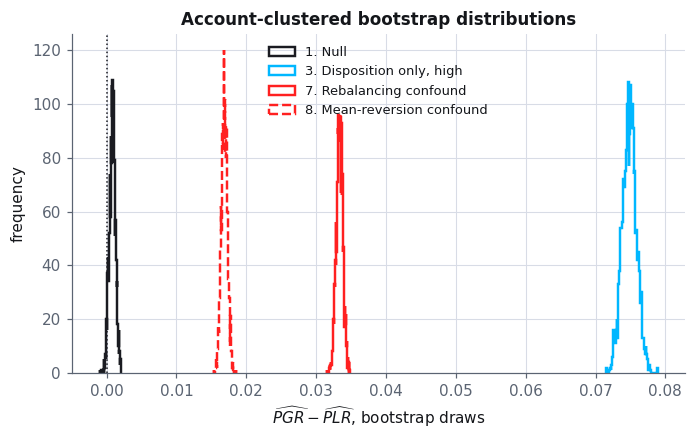

scenario 1: difference 95% CI [-0.00000, +0.00170]   ratio 95% CI [1.000, 1.034]
scenario 3: difference 95% CI [+0.07283, +0.07688]   ratio 95% CI [6.959, 7.842]
scenario 6: difference 95% CI [+0.09560, +0.10149]   ratio 95% CI [6.330, 7.037]
scenario 7: difference 95% CI [+0.03243, +0.03430]   ratio 95% CI [1.803, 1.858]
scenario 8: difference 95% CI [+0.01600, +0.01776]   ratio 95% CI [1.389, 1.440]


In [18]:
draws = {k: (f"{k}. {outputs[k].cfg.name}", outputs[k].boot["draws_diff"], k in (7, 8))
         for k in (1, 3, 7, 8)}
fx.bootstrap_density(draws, f"{FIG}/bootstrap.png"); plt.show()
for k in (1, 3, 6, 7, 8):
    lo, hi = outputs[k].boot["ci_diff"]
    rlo, rhi = outputs[k].boot["ci_ratio"]
    print(f"scenario {k}: difference 95% CI [{lo:+.5f}, {hi:+.5f}]   ratio 95% CI [{rlo:.3f}, {rhi:.3f}]")

Resampling accounts gives standard errors between roughly 1 and 4.6 times those of the naive position-day bootstrap, and the multiple grows with how strongly the effect is concentrated within accounts, since it is about 1 in the null and the overtrading scenarios, where sales really behave like independent coin flips, 2.3 in scenario 3 and 4.6 in scenario 6, where each account's $\delta$ moves all its positions together, so in scenario 6 the naive version inflates the $t$ from 66 to 308. Both reject here, so nothing turns on it in this case, but the same factor applied to a marginal effect manufactures significance out of nothing.

Section 4 adds the more important caveat, because clustering by account handles dependence *within* an account and does nothing about the single market that all accounts share, which is why the null's $t$ of 1.95 in one market coexists with a mean effect of 0.00022 across eight, so on real data account-clustered standard errors are best read as a lower bound on the uncertainty. The overconfidence regression has one observation per account, so no clustering is left to do there, and its HC1 standard errors only correct for the fact that the noise in returns differs across accounts of different size and risk.

---

<a id="s9"></a>

## 9. What the estimators cannot distinguish

The eight scenarios produce three pairs that the headline statistics cannot tell apart, and each pair needs different data to be separated.

**A reference point cannot be told from a weight target.** Scenario 2 injects $\delta = 0.3$ and returns a ratio of 1.74, while scenario 7 injects nothing, rebalances monthly and returns 1.83, and what separates them is the size of each sale relative to the position, which brokerage records usually carry, since rebalancing trims with a mean fraction sold of 0.712 and weighting sales by that fraction collapses its estimate by a factor of 4.4 while leaving the genuine effect untouched, and portfolio weights or a stated target allocation would settle the question outright.

**A reference point cannot be told from a belief about prices.** The traders of scenario 8 never look at their purchase price and still return a ratio of 1.41, because recent returns and gains against the purchase price move together, so what separates the two mechanisms is the recent return of each stock, which is observable. A model of the sale decision that includes both the gain indicator and the recent return would show which one carries the explanatory power, a separation that neither PGR nor PLR can make because both reduce each decision to one comparison against one reference price, and Grinblatt and Han (2005) draw the analogous line on the price side, separating an unrealised capital-gains overhang from past returns.

**A cost of trading cannot be told from an effect of performance on trading.** Wherever selling depends on the purchase price, turnover is partly an outcome of the return, so the regression reads the arrow backwards, with a gross slope of $+0.151$ in scenario 3 although the injected $\delta$ correlates $-0.026$ with gross return. Inside the simulation the remedy is to regress on $\kappa$, which reverses the net slope of scenario 6 from $+0.022$ to $-0.009$, while real data would need something that changes turnover without being changed by returns, such as a change in the commission schedule, a platform migration or a tax rule, or a panel long enough to compare each account with itself over time, since the cross-sectional regression alone cannot do it.

A fourth confusion runs through all of them, since the size of a bias cannot be separated from how often the trader acts on it, as scenario 6 shows by posting a difference 32 % larger than scenario 3 with the same injected $\delta$, and reporting the ratio next to the difference is the minimum defence, while recovering the underlying tilt would require modelling holding periods directly, with a duration model rather than a proportion.

---

<a id="s10"></a>

## 10. Conclusions

| # | Scenario | Disposition, ratio | Turnover slope, net | Verdict |
|---|---|---|---|---|
| 1 | Null | 1.02 | $-0.0047$ | Both quiet |
| 2 | Disposition, low | 1.74 | $+0.0565$ | Disposition recovered, slope spurious |
| 3 | Disposition, high | 7.39 | $+0.1437$ | Disposition recovered, slope spurious |
| 4 | Overtrading, low | 1.00 | $-0.0078$ | Cost recovered |
| 5 | Overtrading, high | 1.00 | $-0.0065$ | Cost recovered, higher drag |
| 6 | Both | 6.67 | $+0.0218$ | Disposition recovered, slope reversed |
| 7 | Rebalancing | 1.83 | $+0.0079$ | Disposition spurious |
| 8 | Belief in reversal | 1.41 | $+0.0580$ | Both spurious |

**Does the simulator recover what it is given?** It does, since the null returns a difference of 0.00085 against a true value of zero, the recovered difference rises through 0.0266 and 0.0749 as $\delta$ goes from 0.3 to 0.8, the disposition estimator stays silent when only $\kappa$ is active, and the net turnover slope comes back at $-0.0078$ and $-0.0065$ against the $-0.005$ cost written into the model, a last result that shows the overconfidence regression measures the commission and spread the account paid rather than a psychological parameter.

**Where do the estimators fail, and why does it matter?** Two scenarios with no injected bias return disposition ratios of 1.83 and 1.41, the first larger than what a genuine $\delta$ of 0.3 produces and both of the order Odean reports for real investors, so a mechanical rebalancing rule and a belief in reversal look like a disposition effect on the headline statistic, and because the estimator computes exactly what it claims, no care in implementing it would have revealed the problem, which only the known ground truth does. The overconfidence regression fails in the opposite direction, since in every scenario where selling depends on gains it reports that trading *raises* returns, an artefact of reverse causality strong enough to reverse the sign of the net slope in scenario 6.

**What should carry over to real data?** Three methodological lessons, because the difference $\widehat{PGR}-\widehat{PLR}$ is not a scale-free measure of the bias and must be reported next to the ratio, because clustering by account can make standard errors 4.6 times larger than the naive version and is still only a lower bound when every account shares one market, and because turnover is an outcome rather than a regressor wherever selling depends on the purchase price. We would ask real data for three things in order, namely the size of each sale relative to the position, which separates rebalancing from a reference point, the recent return of each stock next to its purchase price, which separates a belief about prices from a reference point, and a source of variation in turnover that returns cannot cause, without which the overconfidence coefficient does not mean what it is usually taken to mean.

**What limits these conclusions?** The simulated traders follow simple rules with a single mechanism each, so real investors mixing several motives at once would be harder to separate than our scenarios suggest, and our market has no transaction-driven price impact, no taxes and no calendar effects such as the year-end loss selling documented in the literature. The construction also produced two errors of its own that we corrected rather than hid, a drift specification that mimicked leakage and a leakage test that counted the same purchase a thousand times, and both are recorded in sections 2.1 and 4 because finding them is precisely what a simulation with known ground truth is for.

---

<a id="s11"></a>

## 11. References

1. Barber, B. M., & Odean, T. (2000). Trading Is Hazardous to Your Wealth: The Common Stock Investment Performance of Individual Investors. *The Journal of Finance*, 55(2), 773–806.
2. Barberis, N., & Xiong, W. (2009). What Drives the Disposition Effect? An Analysis of a Long-Standing Preference-Based Explanation. *The Journal of Finance*, 64(2), 751–784.
3. Grinblatt, M., & Han, B. (2005). Prospect Theory, Mental Accounting, and Momentum. *Journal of Financial Economics*, 78(2), 311–339.
4. Odean, T. (1998). Are Investors Reluctant to Realize Their Losses? *The Journal of Finance*, 53(5), 1775–1798.
5. Odean, T. (1999). Do Investors Trade Too Much? *The American Economic Review*, 89(5), 1279–1298.

---

<a id="s12"></a>

## 12. Reproducibility

The simulator lives at the repository root in `src/bfsim/` as seven modules, with `config.py` holding every parameter and the seed policy, `prices.py` the factor model and the leakage test, `agents.py` the population draws, `engine.py` the daily trading loop, `estimators.py` the two estimators and their bootstraps, `scenarios.py` the eight configurations and the tables, and `figures.py` the charts. All randomness descends from a single master seed through separate named streams, so running this notebook from a clean kernel reproduces every number in it exactly, and every table is written to this study's `results/` folder and every figure to `results/figures/`.

In [19]:
import platform, statsmodels, matplotlib
print(f"python      {platform.python_version()}")
for m in (np, pd, statsmodels, matplotlib):
    print(f"{m.__name__:<12}{m.__version__}")
print(f"master seed {MASTER_SEED}")
print(f"scenarios   {len(SCENARIOS)}   traders per scenario {SCENARIOS[0].n_traders}   "
      f"stocks {price_cfg.n_securities}   days {price_cfg.n_days}")

python      3.12.5
numpy       2.1.3
pandas      2.2.3
statsmodels 0.14.5
matplotlib  3.9.2
master seed 20260913
scenarios   8   traders per scenario 1000   stocks 60   days 750
